# MPC Results

Clean analysis notebook for **Occupant-Adaptive RC-MPC with B-spline Dynamic Comfort Preferences**.

This notebook should load fitted models and saved rollouts. It should not define controller classes.

## 1. Experiment Configuration

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.scenarios import SCENARIOS

RESULTS = Path('../results')
SCENARIOS


{'no_occupant': ScenarioConfig(name='no_occupant', occupant_enabled=False, dynamic_comfort_enabled=False, peak_flattening_enabled=False, peak_weight=0.0),
 'occupant_present': ScenarioConfig(name='occupant_present', occupant_enabled=True, dynamic_comfort_enabled=True, peak_flattening_enabled=False, peak_weight=0.0),
 'occupant_present_peak_flattening': ScenarioConfig(name='occupant_present_peak_flattening', occupant_enabled=True, dynamic_comfort_enabled=True, peak_flattening_enabled=True, peak_weight=0.1)}

## 2. RC Model Fit Validation

In [2]:
rc_model_path = RESULTS / 'models' / 'rc' / '1state_rc_247942_january.json'
if rc_model_path.exists():
    rc_params = json.loads(rc_model_path.read_text())
    display(pd.Series(rc_params, name='One-state RC parameters'))
else:
    print(f'Missing fitted model: {rc_model_path}')


cop_a                       1.862284
cop_b                       0.029762
mean_indoor_temperature    18.792767
A                           0.627370
Bd0                         0.276489
Bd1                         0.077632
Bd2                         0.000496
Bu                          7.614534
power_per_unit_action       0.526533
Name: One-state RC parameters, dtype: float64

## 3. Scenario Rollouts

In [3]:
OCCUPANTS = ['occ1_tolerant', 'occ2_sensitive', 'occ3_cold', 'occ4_hot']

MPC_CASES = {
    f'{name}_without_tdyn': ('occupant_present', f'{name}_without_tdyn')
    for name in OCCUPANTS
}
MPC_CASES.update({
    f'{name}_bspline_tdyn': ('occupant_present', f'{name}_bspline_tdyn')
    for name in OCCUPANTS
})

def load_rollout(controller, scenario, case='baseline'):
    base = RESULTS / 'raw' / controller / scenario
    candidates = [
        base / case / 'rollout.parquet',
        base / case / 'rollout.csv',
        base / 'rollout.parquet',
        base / 'rollout.csv',
    ]
    for path in candidates:
        if path.exists():
            return pd.read_parquet(path) if path.suffix == '.parquet' else pd.read_csv(path)
    return pd.DataFrame()

mpc_rollouts = {
    label: load_rollout('mpc', scenario, case)
    for label, (scenario, case) in MPC_CASES.items()
}

rollout_status = pd.DataFrame([
    {
        'case': label,
        'scenario': scenario,
        'result_case': case,
        'loaded': not rollout.empty,
        'steps': len(rollout),
    }
    for label, (scenario, case), rollout in [
        (label, MPC_CASES[label], mpc_rollouts[label]) for label in MPC_CASES
    ]
])
display(rollout_status)

mpc_occ1_without_tdyn = mpc_rollouts['occ1_tolerant_without_tdyn']
mpc_occ1_bspline_tdyn = mpc_rollouts['occ1_tolerant_bspline_tdyn']


,case,scenario,result_case,loaded,steps
0,occ1_tolerant_without_tdyn,occupant_present,occ1_tolerant_without_tdyn,True,671
1,occ2_sensitive_without_tdyn,occupant_present,occ2_sensitive_without_tdyn,True,671
2,occ3_cold_without_tdyn,occupant_present,occ3_cold_without_tdyn,True,671
3,occ4_hot_without_tdyn,occupant_present,occ4_hot_without_tdyn,True,671
4,occ1_tolerant_bspline_tdyn,occupant_present,occ1_tolerant_bspline_tdyn,True,671
5,occ2_sensitive_bspline_tdyn,occupant_present,occ2_sensitive_bspline_tdyn,True,671
6,occ3_cold_bspline_tdyn,occupant_present,occ3_cold_bspline_tdyn,True,671
7,occ4_hot_bspline_tdyn,occupant_present,occ4_hot_bspline_tdyn,True,671


## 4. Temperature Tracking

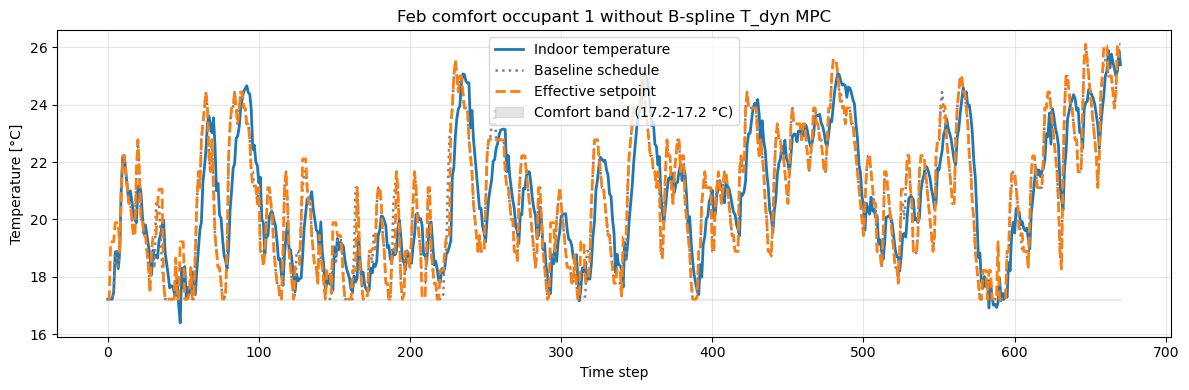

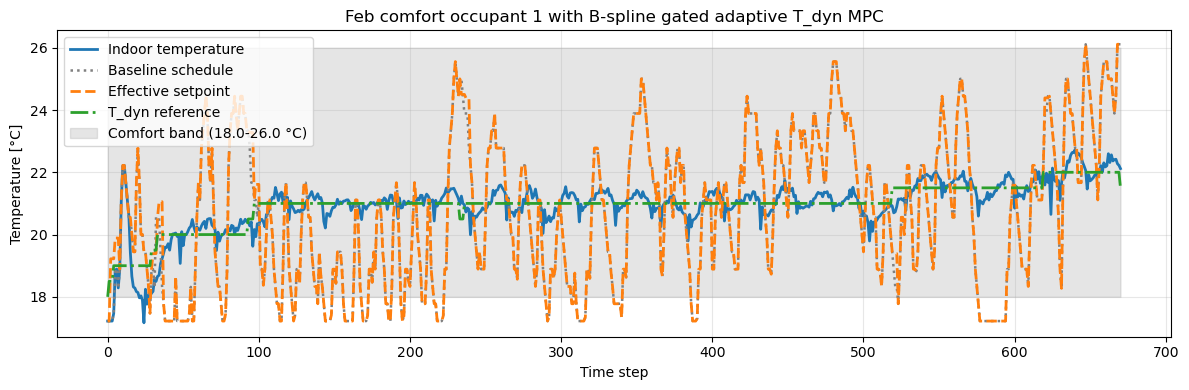

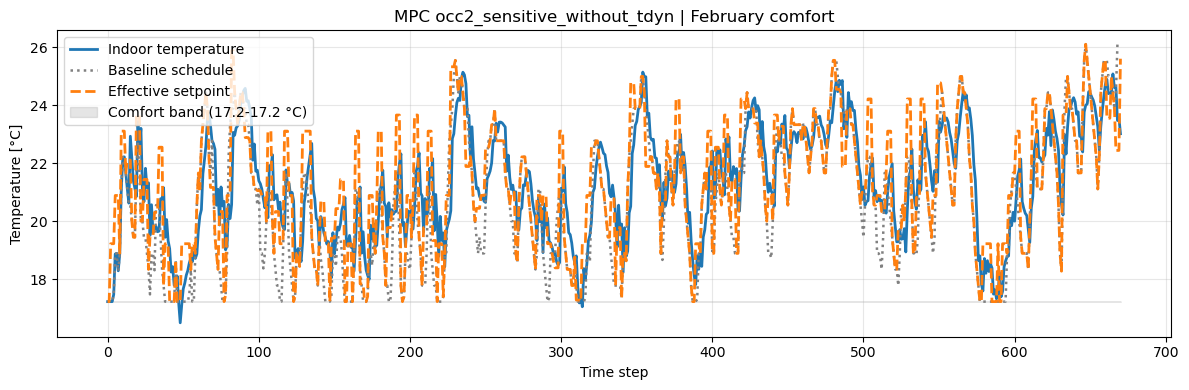

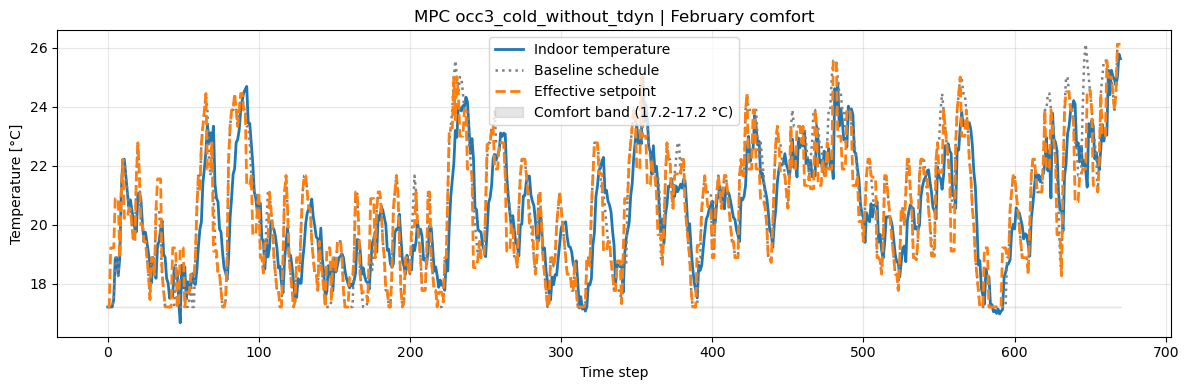

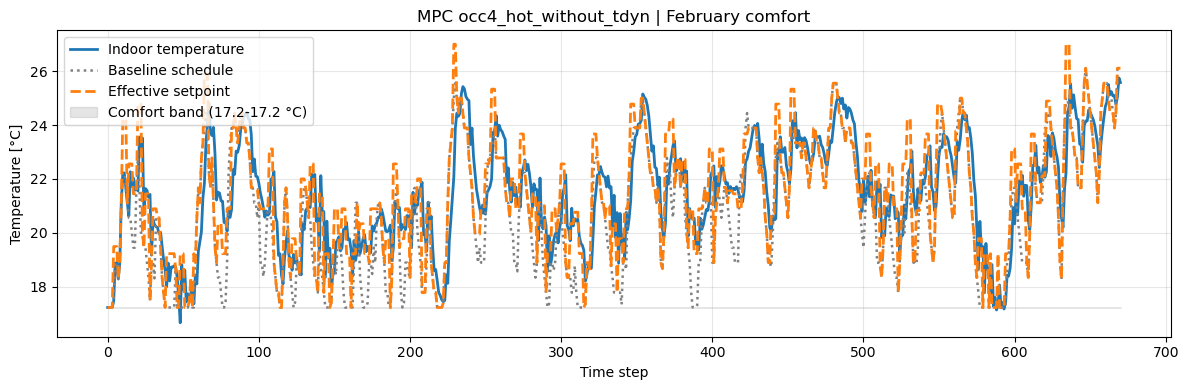

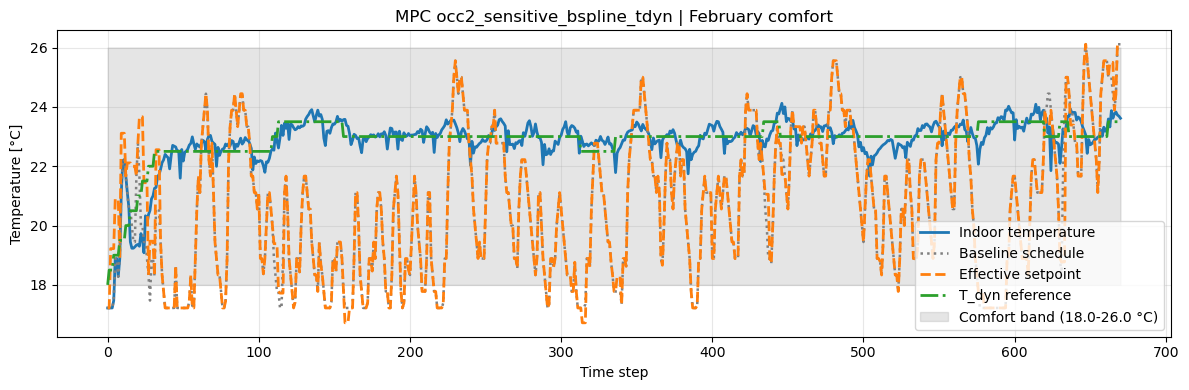

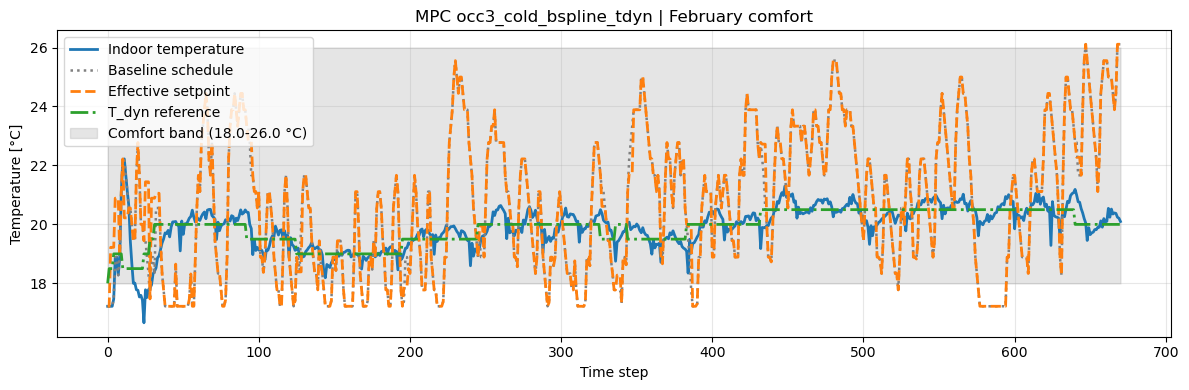

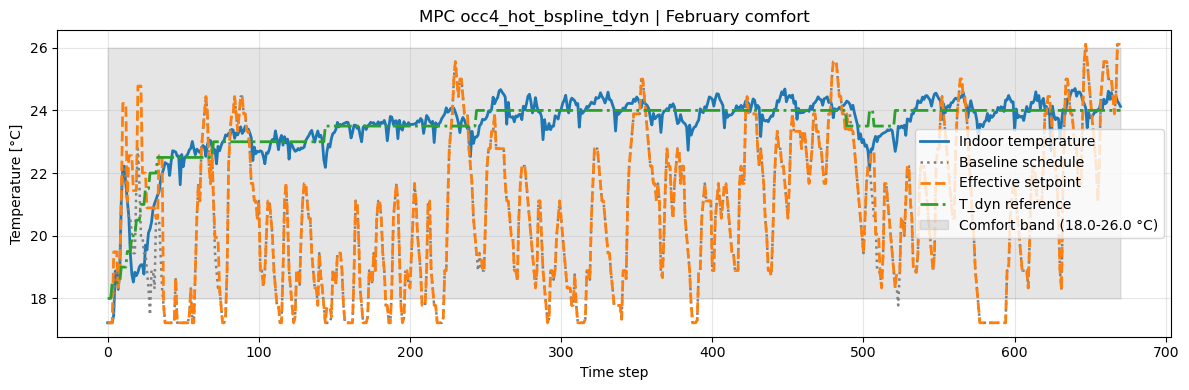

In [4]:
def plot_comfort_from_rollout(history, title='February MPC comfort', T_low=None, T_high=None):
    if history.empty:
        print(f'No rollout loaded for: {title}')
        return None

    x = history['time_step'] if 'time_step' in history else range(len(history))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, history['indoor_temperature'], label='Indoor temperature', linewidth=2)

    if 'baseline_setpoint' in history:
        ax.plot(x, history['baseline_setpoint'], ':', label='Baseline schedule', linewidth=1.8, color='gray')
    elif 'tmin' in history:
        ax.plot(x, history['tmin'], ':', label='Heating setpoint', linewidth=1.8, color='gray')

    if 'effective_setpoint' in history:
        ax.plot(x, history['effective_setpoint'], '--', label='Effective setpoint', linewidth=2)

    if 'tdyn' in history:
        ax.plot(x, history['tdyn'], '-.', label='T_dyn reference', linewidth=2)

    if T_low is None:
        T_low = float(history['tmin'].iloc[0]) if 'tmin' in history else 20.0
    if T_high is None:
        T_high = float(history['tmax'].iloc[0]) if 'tmax' in history else 24.0

    ax.fill_between(x, T_low, T_high, color='gray', alpha=0.2, label=f'Comfort band ({T_low:.1f}-{T_high:.1f} °C)')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return ax

plot_comfort_from_rollout(
    mpc_occ1_without_tdyn,
    title='Feb comfort occupant 1 without B-spline T_dyn MPC',
)
plot_comfort_from_rollout(
    mpc_occ1_bspline_tdyn,
    title='Feb comfort occupant 1 with B-spline gated adaptive T_dyn MPC',
)

for label, rollout in mpc_rollouts.items():
    if label.startswith('occ1_tolerant'):
        continue
    title = f'MPC {label} | February comfort'
    plot_comfort_from_rollout(rollout, title=title)


## 5. Summary Metrics

/tmp/ipykernel_11510/3064465417.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  summary_numeric = summary.apply(pd.to_numeric, errors='ignore')


,case,override_count,reward_total,electricity_consumption_total,discomfort_proportion,discomfort_cold_proportion,discomfort_hot_proportion,daily_peak_average,target_temperature,predicted_occupied_fraction,tdyn_mean,tdyn_final
occ1_tolerant_without_tdyn,occ1_tolerant_without_tdyn,32,-974.710357,1.008102,0.112977,0.070229,0.042748,1.006085,NaN,NaN,NaN,NaN
occ2_sensitive_without_tdyn,occ2_sensitive_without_tdyn,102,-1609.102667,1.030218,0.233588,0.087023,0.146565,1.021000,NaN,NaN,NaN,NaN
occ3_cold_without_tdyn,occ3_cold_without_tdyn,68,-829.214404,0.992356,0.083969,0.073282,0.010687,1.005079,NaN,NaN,NaN,NaN
occ4_hot_without_tdyn,occ4_hot_without_tdyn,100,-1680.032782,1.039226,0.294656,0.076336,0.218321,1.037361,NaN,NaN,NaN,NaN
occ1_tolerant_bspline_tdyn,occ1_tolerant_bspline_tdyn,11,-3330.091018,1.020893,0.471756,0.195420,0.276336,1.018831,21.861014,1.0,20.957526,21.5
occ2_sensitive_bspline_tdyn,occ2_sensitive_bspline_tdyn,21,-6862.060821,1.130543,0.563359,0.048855,0.514504,1.065628,23.035896,1.0,22.880775,23.5
occ3_cold_bspline_tdyn,occ3_cold_bspline_tdyn,16,-3619.031683,0.961734,0.430534,0.329771,0.100763,0.992702,19.957358,1.0,19.894188,20.0
occ4_hot_bspline_tdyn,occ4_hot_bspline_tdyn,16,-8857.836664,1.167811,0.636641,0.027481,0.609160,1.084933,23.909844,1.0,23.511923,24.0


method,with_bspline_tdyn,without_bspline_tdyn
occupant,,
occ1_tolerant,11,32
occ2_sensitive,21,102
occ3_cold,16,68
occ4_hot,16,100


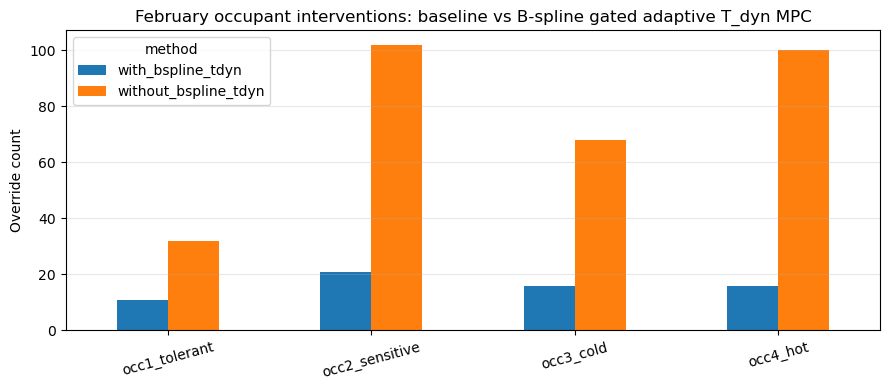

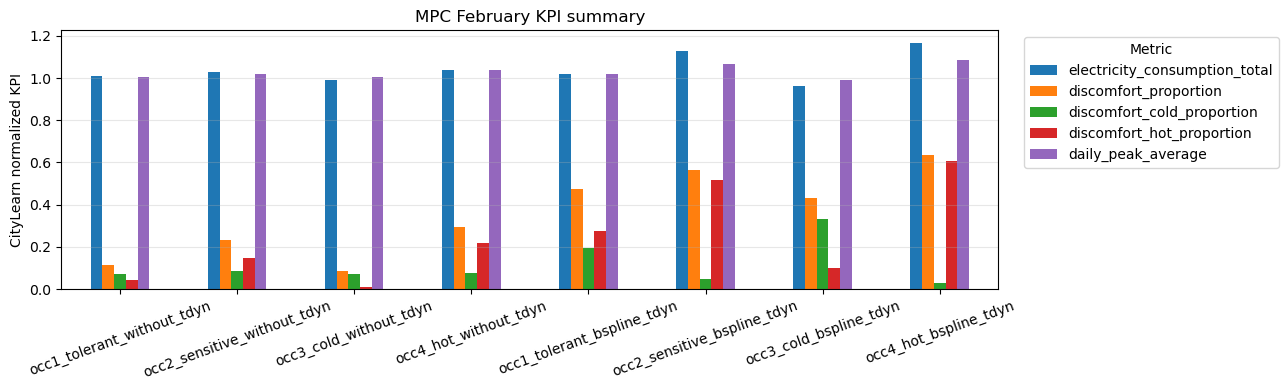

In [5]:
def load_metrics(controller, scenario, case='baseline'):
    candidates = [
        RESULTS / 'summaries' / controller / scenario / f'{case}_metrics.json',
        RESULTS / 'summaries' / controller / scenario / 'metrics.json',
    ]
    for path in candidates:
        if path.exists():
            return json.loads(path.read_text())
    return {}

summary = pd.DataFrame({
    label: load_metrics('mpc', scenario, case)
    for label, (scenario, case) in MPC_CASES.items()
}).T
summary = summary.dropna(how='all')
summary_numeric = summary.apply(pd.to_numeric, errors='ignore')

display(summary_numeric)

if summary_numeric.empty:
    print('No MPC occupant metrics available yet. Run scripts/03_run_mpc.py --scenario occupant_present first.')
else:
    method = np.where(summary_numeric.index.str.contains('bspline_tdyn'), 'with_bspline_tdyn', 'without_bspline_tdyn')
    occupant = summary_numeric.index.str.replace('_bspline_tdyn', '', regex=False).str.replace('_without_tdyn', '', regex=False)
    override_compare = summary_numeric.assign(occupant=occupant, method=method).pivot(
        index='occupant',
        columns='method',
        values='override_count',
    )
    display(override_compare)

    ax = override_compare.plot(kind='bar', figsize=(9, 4), rot=15)
    ax.set_xlabel('')
    ax.set_ylabel('Override count')
    ax.set_title('February occupant interventions: baseline vs B-spline gated adaptive T_dyn MPC')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    kpi_columns = [
        'electricity_consumption_total',
        'discomfort_proportion',
        'discomfort_cold_proportion',
        'discomfort_hot_proportion',
        'daily_peak_average',
    ]
    plot_data = summary_numeric[[c for c in kpi_columns if c in summary_numeric.columns]].apply(pd.to_numeric, errors='coerce')
    plot_data = plot_data.dropna(axis=1, how='all')

    if plot_data.empty:
        print('No KPI metrics available to plot yet.')
    else:
        ax = plot_data.plot(kind='bar', figsize=(13, 4), rot=20)
        ax.set_xlabel('')
        ax.set_ylabel('CityLearn normalized KPI')
        ax.set_title('MPC February KPI summary')
        ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
